# Phase 0: Set up (Runtime = 52s)

In [16]:
#Runtime = 45s

# ============ BOOTSTRAP ============
import subprocess, sys, os
from google.colab import drive, userdata

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Load credentials from Colab Secrets
TOKEN = userdata.get('gitToken')
NAME  = userdata.get('gitName')
EMAIL = userdata.get('gitMail')

# 3. Git identity
!git config --global user.name "{NAME}"
!git config --global user.email "{EMAIL}"

# 4. Clone repo (skip if already cloned)
REPO_DIR = '/content/mit808-2026-project-data-insight-drivers'
if not os.path.exists(REPO_DIR):
    !git clone https://{TOKEN}@github.com/up-mitc-ds/mit808-2026-project-data-insight-drivers.git
else:
    print("Repo already cloned")

# 5. Switch to your branch and sync with master
os.chdir(REPO_DIR)
!git checkout kc/build_zones
!git fetch origin master
!git merge origin/master -m "Sync with master"

# 6. Install dependencies
subprocess.check_call([
    sys.executable, '-m', 'pip', 'install', '-q', '-r',
    os.path.join(REPO_DIR, 'requirements.txt')
])

# 7. Make src/ importable and configure environment
sys.path.insert(0, REPO_DIR)
from src.setup import configure_environment, PATHS, save_and_push
configure_environment()

print("✅ Bootstrap complete — repo at", REPO_DIR)

# ============ IMPORTS ============
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import rasterio
import geopandas as gpd
import earthpy.plot as ep
import contextily as ctx
import laspy
import os
from rasterio.windows import Window

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Repo already cloned
Already on 'kc/build_zones'
Your branch is up to date with 'origin/kc/build_zones'.
From https://github.com/up-mitc-ds/mit808-2026-project-data-insight-drivers
 * branch            master     -> FETCH_HEAD
Already up to date.
✅ All 10 required packages available
✅ Plot defaults configured
✅ Output directories verified
────────────────────────────────────────
🚀 Environment ready
   Data:    /content/drive/MyDrive/MIT/MIT808/melusi-2025-data/raw/
   Repo:    /content/mit808-2026-project-data-insight-drivers
   Figures: /content/mit808-2026-project-data-insight-drivers/reports/figures
✅ Bootstrap complete — repo at /content/mit808-2026-project-data-insight-drivers


In [17]:
#Runtime = 0s

!git status

On branch kc/build_zones
Your branch is up to date with 'origin/kc/build_zones'.

nothing to commit, working tree clean


In [18]:
#Runtime = 7s

# osmnx for OSM road network download
# scipy for Voronoi computation
# Both should already be in requirements.txt — this is a safety install
!pip install osmnx -q
import osmnx as ox
import scipy
print(f'osmnx {ox.__version__} | scipy {scipy.__version__}')

osmnx 2.1.0 | scipy 1.16.3


In [19]:
#Runtime = 0s

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
import osmnx as ox
import matplotlib.pyplot as plt

from shapely.geometry import Point, MultiPoint, box
from shapely.ops import unary_union, voronoi_diagram
from scipy.spatial import Voronoi
from pyproj import Transformer, CRS

# Suppress osmnx info logs
import logging
logging.getLogger('osmnx').setLevel(logging.WARNING)

print('All imports successful.')

All imports successful.


#Phase 1: Load Data (Runtime = 3s)

In [33]:
#Runtime = 2s

# ── CONFIG: update these column names to match your survey DataFrame ───────────
SURVEY_PATH  = r"/content/drive/MyDrive/MIT/MIT808/melusi-2025-data/processed/melusi_df.csv"           # adjust key if different
ZONE_COL     = 'Blocks'          # column identifying the zone (1–15)
COORD_COL_1  = 'Latitude'            # first coordinate column  ← update
COORD_COL_2  = 'Longitude'           # second coordinate column ← update
# ──────────────────────────────────────────────────────────────────────────────

survey = pd.read_csv(SURVEY_PATH) if str(SURVEY_PATH).endswith('.csv') \
         else pd.read_stata(SURVEY_PATH)

# Extract one row per zone (the centroid coordinates should be identical
# for all rows within a zone)
centroids_raw = (
    survey[[ZONE_COL, COORD_COL_1, COORD_COL_2]]
    .dropna()
    .drop_duplicates(subset=ZONE_COL)
    .sort_values(ZONE_COL)
    .reset_index(drop=True)
)

print(f'Zones found: {len(centroids_raw)}')
print(centroids_raw.head(16))

Zones found: 12
    Blocks  Latitude  Longitude
0      1.0 -25.72573   28.10723
1      2.0 -25.72414   28.10620
2      3.0 -25.71910   28.11343
3      4.0 -25.72045   28.12675
4      5.0 -25.72316   28.10751
5      6.0 -25.72460   28.11521
6      7.0 -25.72477   28.11329
7      8.0 -25.72174   28.11503
8      9.0 -25.72662   28.09984
9     10.0 -25.72471   28.10927
10    11.0 -25.72485   28.12639
11    12.0 -25.72149   28.12148


In [34]:
#Runtime = 0s

# Inspect all unique coordinate pairs with their block and dwelling info
coord_summary = survey.groupby(['Longitude', 'Latitude']).agg(
    Blocks=('Blocks', 'first'),
    Dwelling_count=('Dwelling_count', 'first'),  # adjust column name if needed
    Individuals=('Latitude', 'count')
).reset_index()

coord_summary = coord_summary.sort_values('Blocks')

print(f"Total unique coordinate pairs: {len(coord_summary)}")
print()
print(coord_summary.to_string(index=False))

# Flag suspicious coordinates
print("\n\nCOORDINATE QUALITY CHECK")
print("=" * 50)
print(f"Expected Longitude range: ~28.06 – 28.13")
print(f"Expected Latitude range:  ~-25.72 – -25.73")
print()

for _, row in coord_summary.iterrows():
    issues = []

    if not (28.0 < row['Longitude'] < 28.2):
        issues.append(f"Lon {row['Longitude']} outside expected range")

    if not (-25.8 < row['Latitude'] < -25.7):
        issues.append(f"Lat {row['Latitude']} outside expected range")

    if pd.isna(row['Blocks']) or str(row['Blocks']).strip() in ('', 'nan', 'N/A'):
        issues.append("No Block assigned")

    status = "⚠️ " + " | ".join(issues) if issues else "✅ OK"
    print(f"Block {str(row['Blocks']):>4} | Lon {row['Longitude']:>10} | Lat {row['Latitude']:>10} | {row['Individuals']:>5} people | {status}")

Total unique coordinate pairs: 14

 Longitude  Latitude  Blocks  Dwelling_count  Individuals
  28.10723 -25.72573     1.0           743.0          539
  28.10620 -25.72414     2.0           735.0          529
  28.11343 -25.71910     3.0          1345.0          545
  28.12675 -25.72045     4.0           619.0          470
  28.10751 -25.72316     5.0           765.0          557
  28.11521 -25.72460     6.0          1065.0          692
  28.11329 -25.72477     7.0          1332.0         1078
  28.06514 -25.78108     7.0           778.0            1
  28.06717 -25.78389     8.0          1466.0            3
  28.11503 -25.72174     8.0          1106.0          556
  28.09984 -25.72662     9.0           738.0          544
  28.10927 -25.72471    10.0           738.0          599
  28.12639 -25.72485    11.0          1007.0          838
  28.12148 -25.72149    12.0          1655.0         1213


COORDINATE QUALITY CHECK
Expected Longitude range: ~28.06 – 28.13
Expected Latitude range:  ~

In [35]:
#Runtime = 1s

# Define Melusi bounds from the orthophoto
with rasterio.open(PATHS["geotiff"]) as src:
    raster_bounds = src.bounds

# Convert raster bounds (Lo CRS) to WGS84 for comparison
# Melusi WGS84 approximate bounds based on the clean coordinate cluster:
melusi_lon_min, melusi_lon_max = 28.08, 28.14
melusi_lat_min, melusi_lat_max = -25.74, -25.71

# Flag suspect coordinates
before_count = len(survey)

suspect_mask = (
    (survey['Longitude'] < melusi_lon_min) | (survey['Longitude'] > melusi_lon_max) |
    (survey['Latitude'] < melusi_lat_min) | (survey['Latitude'] > melusi_lat_max) |
    pd.isna(survey['Blocks'])
)

suspect = survey[suspect_mask]
print(f"FLAGGED COORDINATES OUTSIDE MELUSI BOUNDS")
print(f"Lon bounds: {melusi_lon_min} – {melusi_lon_max}")
print(f"Lat bounds: {melusi_lat_min} – {melusi_lat_max}")
print(f"=" * 50)
print(f"Suspect rows: {suspect_mask.sum()} / {before_count}")
print()

# Show what's being removed
if len(suspect) > 0:
    print(suspect.groupby(['Blocks', 'Longitude', 'Latitude']).size().reset_index(name='Individuals').to_string(index=False))

# Remove suspect rows
survey_clean = survey[~suspect_mask].copy()
print(f"\nBefore: {before_count:,} rows")
print(f"After:  {len(survey_clean):,} rows")
print(f"Removed: {before_count - len(survey_clean):,} rows")

# Replace original survey so downstream code is unaffected
survey = survey_clean

FLAGGED COORDINATES OUTSIDE MELUSI BOUNDS
Lon bounds: 28.08 – 28.14
Lat bounds: -25.74 – -25.71
Suspect rows: 14 / 8174

 Blocks  Longitude  Latitude  Individuals
    7.0   28.06514 -25.78108            1
    8.0   28.06717 -25.78389            3

Before: 8,174 rows
After:  8,160 rows
Removed: 14 rows


In [36]:
#Runtime = 0s

coord_summary = survey.groupby(['Longitude', 'Latitude']).agg(
    Blocks=('Blocks', 'first'),
    Dwelling_count=('Dwelling_count', 'first'),  # adjust column name if needed
    Individuals=('Latitude', 'count')
).reset_index()

coord_summary = coord_summary.sort_values('Blocks')

print(f"Total unique coordinate pairs: {len(coord_summary)}")

Total unique coordinate pairs: 12


#Phase 2: Detect CRS, Build GDF, and Reproject Centriods (Runtime = 1s)

In [37]:
#Runtime = 0s

c1_vals = centroids_raw[COORD_COL_1].values
c2_vals = centroids_raw[COORD_COL_2].values

def detect_crs(c1, c2):
    """
    Heuristic CRS detection based on coordinate magnitude.
    Lo29 (EPSG:2053): Y ~2,840,000–2,850,000 | X ~87,000–91,000
    WGS84 (EPSG:4326): lat ~-25 to -26    | lon ~28 to 29
    """
    # Check if values look like Lo29 projected (large positive integers)
    if abs(c1[0]) > 1_000_000 or abs(c2[0]) > 1_000_000:
        detected = 'Lo29 (EPSG:2053)'
        epsg = 2053
        # In Lo29, convention is (Y_northing, X_easting)
        # Y is the large value (~2.8M), X is smaller (~88K)
        if abs(c1[0]) > abs(c2[0]):
            northing_col, easting_col = COORD_COL_1, COORD_COL_2
        else:
            northing_col, easting_col = COORD_COL_2, COORD_COL_1
    # Check if values look like WGS84 degrees
    elif -90 <= c1[0] <= 90 and -180 <= c2[0] <= 180:
        detected = 'WGS84 (EPSG:4326)'
        epsg = 4326
        # Convention: (latitude, longitude)
        if c1[0] < 0:   # negative = southern hemisphere = latitude
            northing_col, easting_col = COORD_COL_1, COORD_COL_2
        else:
            northing_col, easting_col = COORD_COL_2, COORD_COL_1
    else:
        detected = 'Unknown'
        epsg = None
        northing_col, easting_col = COORD_COL_1, COORD_COL_2

    return detected, epsg, northing_col, easting_col

detected_crs, source_epsg, northing_col, easting_col = detect_crs(c1_vals, c2_vals)

print(f'Detected CRS : {detected_crs}')
print(f'Northing col : {northing_col}  (sample: {centroids_raw[northing_col].values[:3]})')
print(f'Easting col  : {easting_col}   (sample: {centroids_raw[easting_col].values[:3]})')
print()
print('>>> If this looks wrong, manually set source_epsg, northing_col, easting_col below.')

# ── MANUAL OVERRIDE (uncomment and edit if auto-detection was wrong) ───────────
# source_epsg  = 2053
# northing_col = 'gps_latitude'
# easting_col  = 'gps_longitude'
# ──────────────────────────────────────────────────────────────────────────────

Detected CRS : WGS84 (EPSG:4326)
Northing col : Latitude  (sample: [-25.72573 -25.72414 -25.7191 ])
Easting col  : Longitude   (sample: [28.10723 28.1062  28.11343])

>>> If this looks wrong, manually set source_epsg, northing_col, easting_col below.


In [39]:
#Runtime = 0s

# Build GeoDataFrame in source CRS
geometry = [
    Point(row[easting_col], row[northing_col])
    for _, row in centroids_raw.iterrows()
]
gdf_centroids = gpd.GeoDataFrame(
    centroids_raw[[ZONE_COL]].copy(),
    geometry=geometry,
    crs=f'EPSG:{source_epsg}'
)

# Reproject to WGS84 for OSM download
gdf_centroids_wgs = gdf_centroids.to_crs('EPSG:4326')

# Reproject to Lo29 for metric operations
gdf_centroids_lo29 = gdf_centroids.to_crs('EPSG:2053')

print('Centroids in WGS84:')
print(gdf_centroids_wgs[['Blocks', 'geometry']].to_string())

Centroids in WGS84:
    Blocks                    geometry
0      1.0  POINT (28.10723 -25.72573)
1      2.0   POINT (28.1062 -25.72414)
2      3.0   POINT (28.11343 -25.7191)
3      4.0  POINT (28.12675 -25.72045)
4      5.0  POINT (28.10751 -25.72316)
5      6.0   POINT (28.11521 -25.7246)
6      7.0  POINT (28.11329 -25.72477)
7      8.0  POINT (28.11503 -25.72174)
8      9.0  POINT (28.09984 -25.72662)
9     10.0  POINT (28.10927 -25.72471)
10    11.0  POINT (28.12639 -25.72485)
11    12.0  POINT (28.12148 -25.72149)


#Phase 3: Define Melusi Boundaries from GeoTiff (Runtime = 1s)

In [40]:
#Runtime = 0s

# Try GeoTIFF first, fall back to ECW
raster_path = None
for key in ['geotiff', 'ecw']:
    if key in PATHS and os.path.exists(PATHS[key]):
        raster_path = PATHS[key]
        print(f'Using raster: {key} → {raster_path}')
        break

if raster_path is None:
    raise FileNotFoundError(
        'Neither geotiff nor ecw found in PATHS. '
        'Check that Google Drive is mounted and PATHS keys are correct.'
    )

with rasterio.open(raster_path) as src:
    bounds = src.bounds
    raster_crs = src.crs
    print(f'Raster CRS   : {raster_crs}')
    print(f'Raster bounds: {bounds}')

# --- CRS handling (robust to malformed axis definitions) ---
def resolve_crs(crs):
    """Return a safe CRS, overriding known problematic definitions."""
    if crs is None:
        print('CRS missing → assuming EPSG:2053 (Lo29)')
        return 'EPSG:2053'

    crs_str = crs.to_string()

    # Detect problematic South-orientated CRS
    if 'South_Orientated' in crs_str or 'AXIS' in crs_str:
        print('Non-standard CRS detected → overriding to EPSG:2053 (Lo29)')
        return 'EPSG:2053'

    return crs

safe_crs = resolve_crs(raster_crs)

# Build boundary polygon
settlement_bbox = box(bounds.left, bounds.bottom, bounds.right, bounds.top)
gdf_boundary_native = gpd.GeoDataFrame(
    {'id': [1]},
    geometry=[settlement_bbox],
    crs=safe_crs
)

# Reproject
gdf_boundary_wgs  = gdf_boundary_native.to_crs('EPSG:4326')
gdf_boundary_lo29 = gdf_boundary_native.to_crs('EPSG:2053')

print('\nBoundary in WGS84 bounds:', gdf_boundary_wgs.total_bounds)

Using raster: geotiff → /content/drive/MyDrive/MIT/MIT808/melusi-2025-data/raw/GeoTIFF/Melusi_07032025Tif.tif
Raster CRS   : PROJCS["unnamed",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.25722356049,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator_South_Orientated"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",0],PARAMETER["scale_factor",1],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1],AXIS["Easting",WEST],AXIS["Northing",SOUTH]]
Raster bounds: BoundingBox(left=87510.2477853935, bottom=2845792.73399531, right=90592.14778539349, top=2847047.18399531)
Non-standard CRS detected → overriding to EPSG:2053 (Lo29)

Boundary in WGS84 bounds: [ 28.09723346 -25.72851691  28.12802482 -25.71700787]


#Phase 4: OSM Section (Runtime = 5s)

In [41]:
#Runtime = 0s

import osmnx as ox
import geopandas as gpd

# Load the OSM XML file from Drive
osm_path = PATHS["data_raw"] + "melusi_osm"

# Check if it needs the .xml extension
print(os.path.exists(osm_path))
print(os.path.exists(osm_path + ".xml"))

True
False


In [42]:
#Runtime = 4s

# Load graph from local OSM XML file
G = ox.graph_from_xml(osm_path)

print(f"Nodes: {len(G.nodes)}")
print(f"Edges: {len(G.edges)}")

# Convert to GeoDataFrame
edges_wgs = ox.graph_to_gdfs(G, nodes=False, edges=True)
print(f"Road segments: {len(edges_wgs)}")
print(f"Highway types: {edges_wgs['highway'].explode().unique()}")

Nodes: 1269
Edges: 3657
Road segments: 3657
Highway types: ['residential' 'service' 'footway' nan 'path' 'secondary' 'track'
 'secondary_link' 'unclassified']


In [43]:
#Runtime = 0s

# Reproject edges to Lo29 for metric operations
edges_lo29 = edges_wgs.to_crs('EPSG:2053')

# Clip to settlement boundary (removes roads outside the orthophoto extent)
edges_lo29 = gpd.clip(edges_lo29, gdf_boundary_lo29)
print(f'Edges after clipping to settlement: {len(edges_lo29)}')

Edges after clipping to settlement: 2199


#Phase 5: Densify and assign roads (Runtime = 2s)

In [44]:
#Runtime = 0s

from shapely.geometry import LineString

POINT_SPACING_M = 3.0   # sample a point every 3 metres along each road

def densify_line(geom, spacing):
    """Return list of Points sampled at `spacing` metres along a LineString."""
    if geom is None or geom.is_empty:
        return []
    length = geom.length
    if length == 0:
        return [geom.interpolate(0)]
    n_points = max(2, int(length / spacing))
    return [geom.interpolate(i / n_points, normalized=True)
            for i in range(n_points + 1)]

road_points = []
for geom in edges_lo29.geometry:
    if geom.geom_type == 'LineString':
        road_points.extend(densify_line(geom, POINT_SPACING_M))
    elif geom.geom_type == 'MultiLineString':
        for part in geom.geoms:
            road_points.extend(densify_line(part, POINT_SPACING_M))

print(f'Road points generated: {len(road_points):,} at {POINT_SPACING_M}m spacing')

Road points generated: 50,532 at 3.0m spacing


In [45]:
#Runtime = 1s

from scipy.spatial import cKDTree

# Extract centroid coordinates in Lo29 as array
centroid_coords = np.array([
    [pt.x, pt.y] for pt in gdf_centroids_lo29.geometry
])
zone_ids = gdf_centroids_lo29[ZONE_COL].values

# Build KD-tree for fast nearest-neighbour lookup
tree = cKDTree(centroid_coords)

# For every road point, find the nearest centroid
road_coords = np.array([[pt.x, pt.y] for pt in road_points])
_, nearest_idx = tree.query(road_coords)
road_zone_labels = zone_ids[nearest_idx]

# Build a GeoDataFrame of labelled road points
gdf_road_pts = gpd.GeoDataFrame(
    {ZONE_COL: road_zone_labels},
    geometry=road_points,
    crs='EPSG:2053'
)

print(f'Road points labelled. Zone distribution:')
print(gdf_road_pts[ZONE_COL].value_counts().sort_index())

Road points labelled. Zone distribution:
Blocks
1.0     2622
2.0     5390
3.0     4680
4.0     2320
5.0     6406
6.0     3348
7.0     2710
8.0     3778
9.0     5442
10.0    3602
11.0    3920
12.0    6314
Name: count, dtype: int64


#Phase 6: Compute Voronoi abd dissolve into Zone Polygons (Runtime = 5s)

In [46]:
#Runtime = 1s

# Combine road points + zone centroids into one point set for Voronoi
all_pts_coords = np.vstack([
    road_coords,
    centroid_coords
])
all_labels = np.concatenate([
    road_zone_labels,
    zone_ids
])

# Compute Voronoi regions using shapely's voronoi_diagram
# We pass the settlement boundary as the envelope to clip infinite regions
boundary_poly = gdf_boundary_lo29.geometry.iloc[0]

multi_pt = MultiPoint(all_pts_coords.tolist())
print('Computing Voronoi diagram (may take 30–90s for large point sets)...')
vd = voronoi_diagram(multi_pt, envelope=boundary_poly)
print(f'Voronoi regions: {len(list(vd.geoms))}')

Computing Voronoi diagram (may take 30–90s for large point sets)...
Voronoi regions: 23732


In [49]:
print("test")

test


In [52]:
# Build GeoDataFrame of all input points with labels
gdf_all_pts = gpd.GeoDataFrame(
    {ZONE_COL: all_labels},
    geometry=[Point(x, y) for x, y in all_pts_coords],
    crs='EPSG:2053'
)

# Convert Voronoi cells to GeoDataFrame
voronoi_cells = list(vd.geoms)
gdf_voronoi = gpd.GeoDataFrame(
    {'cell_id': range(len(voronoi_cells))},
    geometry=voronoi_cells,
    crs='EPSG:2053'
)

# For each cell, find its nearest centroid instead of checking containment
cell_centroids = np.array([[cell.centroid.x, cell.centroid.y] for cell in voronoi_cells])
_, nearest_idx = tree.query(cell_centroids)
gdf_voronoi[ZONE_COL] = zone_ids[nearest_idx]

# Dissolve by zone label → 12 zone polygons
gdf_zones_lo29 = (
    gdf_voronoi
    .dissolve(by=ZONE_COL)
    .reset_index()
    .clip(gdf_boundary_lo29)
)

print(f'Zone polygons produced: {len(gdf_zones_lo29)}')
print(gdf_zones_lo29[[ZONE_COL, 'geometry']].head())

Zone polygons produced: 12
    Blocks                                           geometry
3      4.0  MULTIPOLYGON (((87510.644 2846506.87, 87513.70...
11    12.0  POLYGON ((87960.22 2845891.025, 87957.67 28458...
7      8.0  MULTIPOLYGON (((88495.777 2845973.754, 88495.1...
5      6.0  MULTIPOLYGON (((88373.719 2846649.924, 88372.2...
6      7.0  POLYGON ((88921.335 2846505.763, 88920.134 284...


In [56]:
#Runtime = 0s

# Area in square metres (Lo29 is a metric CRS)
gdf_zones_lo29['area_m2'] = gdf_zones_lo29.geometry.area
gdf_zones_lo29['area_ha'] = gdf_zones_lo29['area_m2'] / 10_000

# WGS84 version for web mapping / OSM overlays
gdf_zones_wgs = gdf_zones_lo29.to_crs('EPSG:4326')

print('Zone area summary (hectares):')
print(gdf_zones_lo29[['Blocks', 'area_m2']].to_string(index=False))
print(f'\nTotal area: {gdf_zones_lo29["area_m2"].sum():.2f} m^2')

Zone area summary (hectares):
 Blocks       area_m2
    4.0 245968.253657
   12.0 490857.108230
    8.0 212332.815815
    6.0 319574.054728
    7.0 206891.684317
   11.0 393596.000131
    3.0 353177.221865
    5.0 407460.033596
    2.0 330806.584809
    9.0 563100.373016
   10.0 147195.204033
    1.0 195130.120804

Total area: 3866089.46 m^2


#Phase 7: Validation Plot (Runtime = 5s)

/tmp/ipykernel_28431/915863575.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap('tab20', len(gdf_zones_clipped))


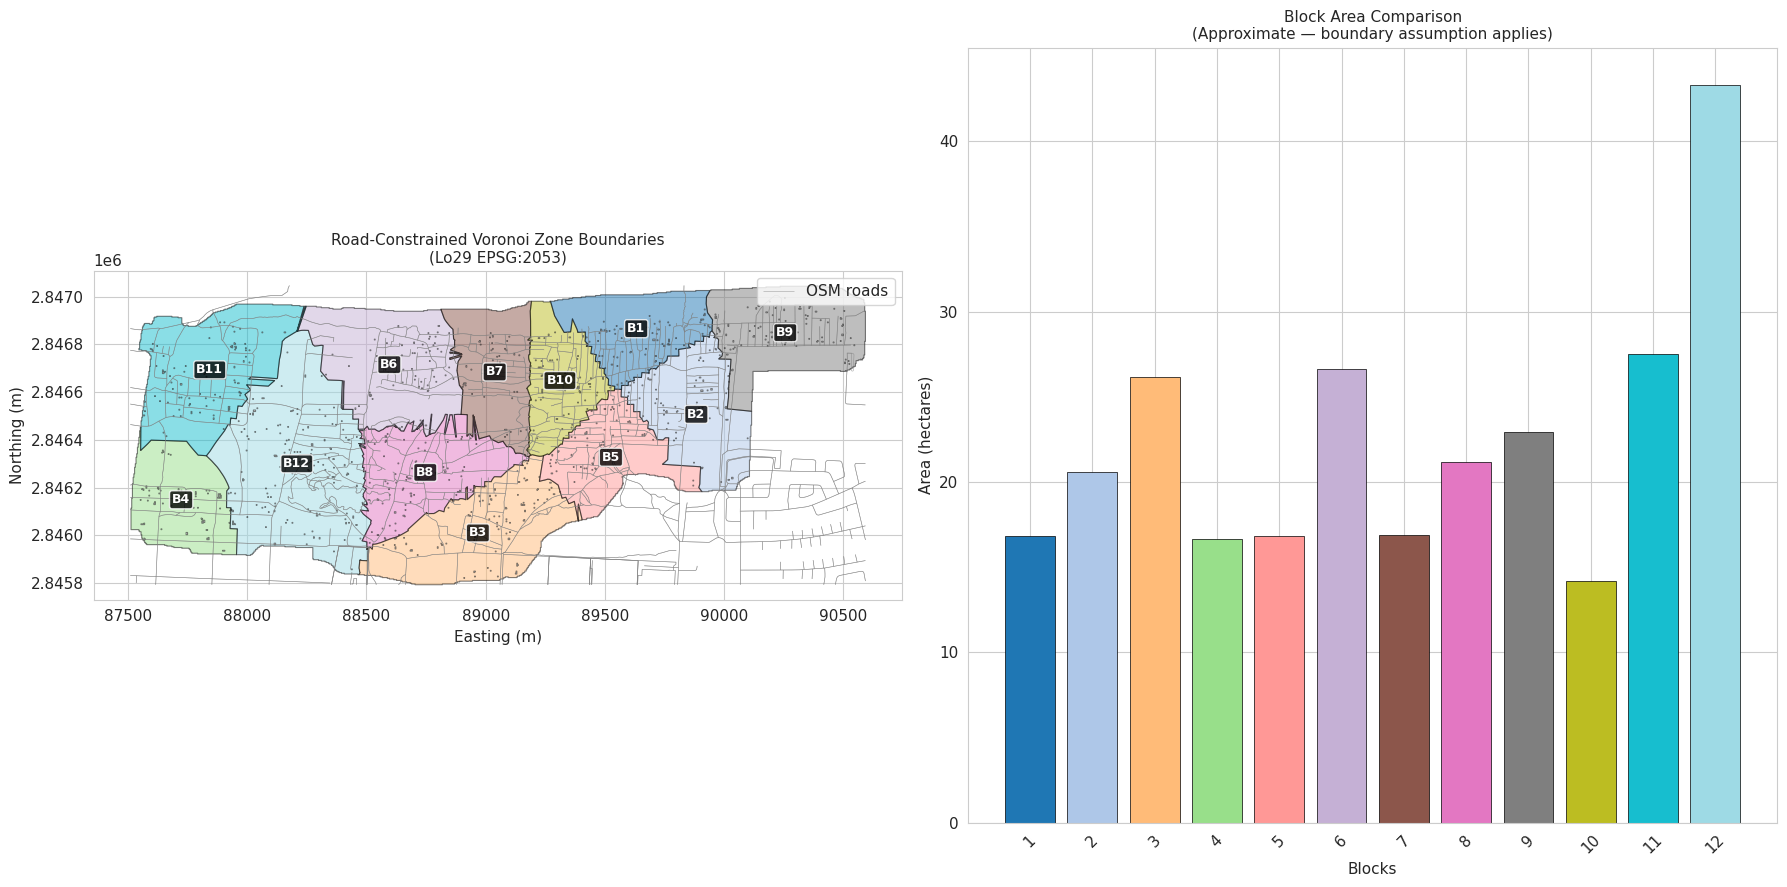

In [65]:
import matplotlib.patches as mpatches
from matplotlib.cm import get_cmap

fig, axes = plt.subplots(1, 2, figsize=(18, 9))
cmap = get_cmap('tab20', len(gdf_zones_clipped))

# ── Left: Zones with road network overlay ─────────────────────────────────────
ax = axes[0]
gdf_zones_clipped.plot(ax=ax, column=ZONE_COL, cmap='tab20',
                       alpha=0.5, edgecolor='black', linewidth=0.8)
edges_lo29.plot(ax=ax, color='grey', linewidth=0.4, alpha=0.7, label='OSM roads')

# Label zones
for _, row in gdf_zones_clipped.iterrows():
    if row.geometry.is_empty:
        continue
    centroid = row.geometry.centroid
    ax.text(
        centroid.x, centroid.y,
        f"B{int(row[ZONE_COL])}",
        fontsize=9, fontweight='bold', color='white',
        ha='center', va='center',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='black', alpha=0.8)
    )

ax.set_title('Road-Constrained Voronoi Zone Boundaries\n(Lo29 EPSG:2053)', fontsize=11)
ax.set_xlabel('Easting (m)')
ax.set_ylabel('Northing (m)')
ax.legend()

# ── Right: Zone areas bar chart ────────────────────────────────────────────────
ax2 = axes[1]

# Recalculate areas from clipped zones
gdf_zones_clipped['area_ha'] = gdf_zones_clipped.geometry.area / 10000

sorted_zones = gdf_zones_clipped.sort_values(ZONE_COL)
bars = ax2.bar(
    sorted_zones[ZONE_COL].astype(int).astype(str),
    sorted_zones['area_ha'],
    color=[cmap(i) for i in range(len(sorted_zones))],
    edgecolor='black', linewidth=0.5
)
ax2.set_title('Block Area Comparison\n(Approximate — boundary assumption applies)', fontsize=11)
ax2.set_xlabel('Blocks')
ax2.set_ylabel('Area (hectares)')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(PATHS["figures"] + "/zone_boundaries_validation.png", dpi=150, bbox_inches='tight')
plt.show()

In [22]:
#Runtime = 0s

import os
os.makedirs('data/processed', exist_ok=True)

# Lo29 — primary working CRS (metric, matches orthophoto and LiDAR)
out_lo29 = 'data/processed/zone_boundaries_lo29.geojson'
gdf_zones_lo29.to_file(out_lo29, driver='GeoJSON')
print(f'Saved (Lo29):  {out_lo29}')

# WGS84 — for web mapping and OSM overlay
out_wgs = 'data/processed/zone_boundaries_wgs84.geojson'
gdf_zones_wgs.to_file(out_wgs, driver='GeoJSON')
print(f'Saved (WGS84): {out_wgs}')

# Zone centroid points (useful for later joins)
out_centroids = 'data/processed/zone_centroids_lo29.geojson'
gdf_centroids_lo29.to_file(out_centroids, driver='GeoJSON')
print(f'Saved centroids: {out_centroids}')

Saved (Lo29):  data/processed/zone_boundaries_lo29.geojson
Saved (WGS84): data/processed/zone_boundaries_wgs84.geojson
Saved centroids: data/processed/zone_centroids_lo29.geojson


In [59]:
from shapely.geometry import shape
from rasterio.features import shapes

with rasterio.open(PATHS["geotiff"]) as src:
    # Read downsampled brightness to create a data mask
    scale = 100
    small = src.read(
        [1, 2, 3],
        out_shape=(3, src.height // scale, src.width // scale)
    )

    # Mask: pixels where NOT all bands are 255 (i.e., actual data)
    brightness = small.mean(axis=0)
    data_mask = (brightness < 250).astype(np.uint8)

    # Get the transform for the downsampled resolution
    transform = src.transform * src.transform.scale(
        src.width / (src.width // scale),
        src.height / (src.height // scale)
    )

    # Convert mask to polygon
    mask_shapes = list(shapes(data_mask, mask=data_mask == 1, transform=transform))

    # Take the largest polygon (the main settlement footprint)
    polys = [shape(s) for s, v in mask_shapes]
    data_boundary = max(polys, key=lambda p: p.area)

# Create GeoDataFrame of the data boundary
gdf_data_boundary = gpd.GeoDataFrame(
    geometry=[data_boundary],
    crs=src.crs
)

print(f"Data boundary area: {data_boundary.area:,.0f} m²")
print(f"Data boundary area: {data_boundary.area / 10000:.1f} hectares")

# Re-clip the Voronoi zones to the actual data boundary
gdf_zones_clipped = gdf_zones_lo29.copy()
gdf_zones_clipped['geometry'] = gdf_zones_clipped.geometry.intersection(data_boundary)

# Remove any empty geometries
gdf_zones_clipped = gdf_zones_clipped[~gdf_zones_clipped.is_empty]

print(f"Zones clipped to data boundary: {len(gdf_zones_clipped)}")

Data boundary area: 2,696,661 m²
Data boundary area: 269.7 hectares
Zones clipped to data boundary: 12


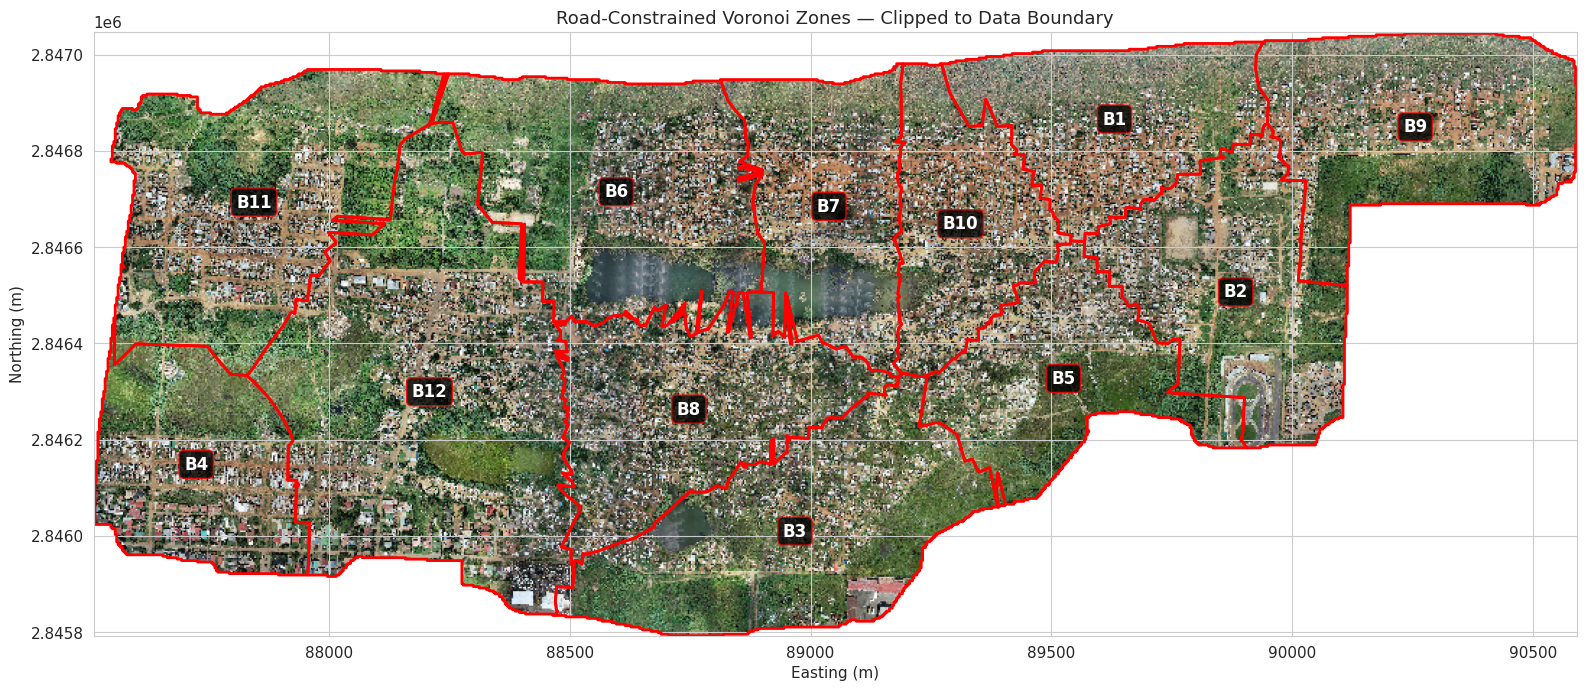

In [64]:
fig, ax = plt.subplots(figsize=(16, 8))

ax.imshow(
    np.moveaxis(small, 0, -1),
    extent=[src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top],
    origin='upper'
)

# Draw zone boundaries
for _, row in gdf_zones_clipped.iterrows():
    geom = row.geometry
    if geom.is_empty:
        continue
    if geom.geom_type == 'MultiPolygon':
        polys = list(geom.geoms)
    else:
        polys = [geom]
    for poly in polys:
        xs, ys = poly.exterior.xy
        ax.plot(xs, ys, color='red', linewidth=2)

# Labels — larger, white text on black background
for _, row in gdf_zones_clipped.iterrows():
    if row.geometry.is_empty:
        continue
    centroid = row.geometry.centroid
    ax.text(
        centroid.x, centroid.y,
        f"B{int(row[ZONE_COL])}",
        fontsize=12, fontweight='bold', color='white',
        ha='center', va='center',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='black', alpha=0.8, edgecolor='red')
    )

ax.set_xlabel('Easting (m)')
ax.set_ylabel('Northing (m)')
ax.set_title('Road-Constrained Voronoi Zones — Clipped to Data Boundary')
ax.set_aspect('equal')

plt.tight_layout()
plt.savefig(PATHS["figures"] + "/voronoi_clipped_clean.jpg", dpi=150, format='jpeg')
plt.show()

#Debug

In [26]:
# What zones do we have in the Voronoi output?
print("Zones in Voronoi:", sorted(gdf_centroids_lo29['Dwelling_count'].unique()))
print(f"Count: {len(gdf_centroids_lo29)}")

# What zones should we have from the survey?
expected = sorted(survey['Dwelling_count'].unique())
print(f"\nExpected zones: {expected}")
print(f"Count: {len(expected)}")

# Which one is missing?
missing = set(expected) - set(gdf_centroids_lo29['Dwelling_count'].unique())
print(f"\nMissing zone(s): {missing}")

Zones in Voronoi: [np.float64(619.0), np.float64(735.0), np.float64(738.0), np.float64(743.0), np.float64(765.0), np.float64(778.0), np.float64(1007.0), np.float64(1065.0), np.float64(1106.0), np.float64(1332.0), np.float64(1345.0), np.float64(1466.0), np.float64(1655.0)]
Count: 13

Expected zones: [np.float64(619.0), np.float64(735.0), np.float64(738.0), np.float64(743.0), np.float64(765.0), np.float64(1007.0), np.float64(1065.0), np.float64(1106.0), np.float64(1332.0), np.float64(1345.0), np.float64(1655.0)]
Count: 11

Missing zone(s): set()


In [29]:
# Check which Dwelling_counts are in the Voronoi but not in the clean survey
extra = set(gdf_centroids_lo29['Dwelling_count'].unique()) - set(survey_clean['Dwelling_count'].unique())
print(f"Extra zones to remove: {extra}")



Extra zones to remove: {np.float64(1466.0), np.float64(778.0)}


In [32]:
print(coord_summary[['Blocks', 'Dwelling_count', 'Longitude', 'Latitude', 'Individuals']].to_string(index=False))

 Blocks  Dwelling_count  Longitude  Latitude  Individuals
    1.0           743.0   28.10723 -25.72573          539
    2.0           735.0   28.10620 -25.72414          529
    3.0          1345.0   28.11343 -25.71910          545
    4.0           619.0   28.12675 -25.72045          470
    5.0           765.0   28.10751 -25.72316          557
    6.0          1065.0   28.11521 -25.72460          692
    7.0          1332.0   28.11329 -25.72477         1078
    8.0          1106.0   28.11503 -25.72174          556
    9.0           738.0   28.09984 -25.72662          544
   10.0           738.0   28.10927 -25.72471          599
   11.0          1007.0   28.12639 -25.72485          838
   12.0          1655.0   28.12148 -25.72149         1213


#Phase X: Git -push and -Commit

In [66]:
save_and_push("kc_boundaries.ipynb", "(1) Fixed Phase 3 CRS issue (2) Added logging to Phase 4 OSM download (3) Finalised Boundary definitions using Voronoi algorithm")

📋 Copied kc_boundaries.ipynb into repo
✅ Pushed kc_boundaries.ipynb to kc/build_zones
